# JumpGuard AI - Biomechanical Feature Engineering

This notebook uses the Prompt 2 `Dataset`, `Participant`, and `Trial` abstractions. Features are computed over full recordings because the local dataset sources do not define the K/A event suffixes. No risk scores or undocumented landing segmentation are used.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import Dataset, FeatureExtractor
from src.feature_engineering import (
    export_features,
    plot_correlation_heatmap,
    plot_feature_distribution,
    plot_left_right_comparison,
    plot_time_series_overlay,
    validate_feature_table,
)

MAT_PATH = PROJECT_ROOT / 'data/sample/DJ.mat'
OUTPUT_PATH = PROJECT_ROOT / 'data/processed/features.csv'

## 2. Load the Prompt 2 Dataset

In [2]:
dataset = Dataset.load(MAT_PATH)
dataset.summary()

{'participants': 43,
 'participant_ids': [1,
  2,
  3,
  4,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 'total_trial_slots': 258,
 'valid_trials': 249,
 'empty_trials': 9,
 'joint_angle_labels': 44,
 'frame_min': 842,
 'frame_max': 2280,
 'frame_mean': 1401.120481927711,
 'frame_median': 1395.0}

## 3. Extract a Single Trial

In [3]:
extractor = FeatureExtractor()
trial = dataset.get_participant('sub01').get_trial('DJ_t1')
trial_features = trial.extract_features(extractor)
{
    'feature_count': len(trial_features),
    'knee_flexion_right_rom': trial_features['knee_flexion_right_rom'],
    'knee_flexion_rom_symmetry_index': trial_features['knee_flexion_rom_symmetry_index'],
}

{'feature_count': 57,
 'knee_flexion_right_rom': 85.9912138,
 'knee_flexion_rom_symmetry_index': -5.2099874976267335}

## 4. Extract and Validate the Complete Dataset

In [4]:
feature_frame = dataset.extract_features(extractor)
validate_feature_table(feature_frame, extractor.feature_names)
{
    'shape': feature_frame.shape,
    'feature_columns': len(extractor.feature_names),
    'valid_rows': int((~feature_frame['is_empty']).sum()),
    'empty_rows': int(feature_frame['is_empty'].sum()),
    'duplicate_columns': int(feature_frame.columns.duplicated().sum()),
    'duplicate_trial_rows': int(feature_frame.duplicated(['participant_id', 'trial_slot']).sum()),
}

{'shape': (258, 62),
 'feature_columns': 57,
 'valid_rows': 249,
 'empty_rows': 9,
 'duplicate_columns': 0,
 'duplicate_trial_rows': 0}

In [5]:
feature_frame.head()

,participant_id,trial_slot,trial_name,condition,is_empty,hip_flexion_right_mean,hip_flexion_right_median,hip_flexion_right_std,hip_flexion_right_variance,hip_flexion_right_maximum,...,ankle_angle_left_time_to_peak,hip_flexion_rom_absolute_difference,hip_flexion_rom_percent_difference,hip_flexion_rom_symmetry_index,knee_flexion_rom_absolute_difference,knee_flexion_rom_percent_difference,knee_flexion_rom_symmetry_index,ankle_angle_rom_absolute_difference,ankle_angle_rom_percent_difference,ankle_angle_rom_symmetry_index
0,1,1,DJ_t1,nonfatigued,False,28.376651,23.701872,27.405715,751.073217,68.164050,...,2.276,0.979664,1.413547,-1.413547,4.366387,5.209987,-5.209987,5.101141,7.266844,7.266844
1,1,2,DJ_t2,nonfatigued,False,30.593847,27.038234,26.651106,710.281435,67.908487,...,2.696,0.085569,0.126384,-0.126384,3.534535,4.221223,-4.221223,3.095924,4.359442,-4.359442
2,1,3,DJ_t3,nonfatigued,False,30.200640,38.438301,26.342003,693.901105,70.539970,...,2.912,2.176743,3.012012,-3.012012,0.329251,0.409251,-0.409251,1.243933,1.883727,1.883727
3,1,4,f_DJ_t1,fatigued,False,38.172830,42.057721,28.317695,801.891831,76.495912,...,2.284,3.197789,4.234271,-4.234271,2.274427,2.572344,-2.572344,0.411030,0.572724,0.572724
4,1,5,f_DJ_t2,fatigued,False,33.729410,33.005348,28.235232,797.228348,70.270793,...,2.784,0.704636,1.014404,-1.014404,0.727023,0.885667,0.885667,1.238576,1.782882,1.782882


## 5. Feature Distribution and Histogram

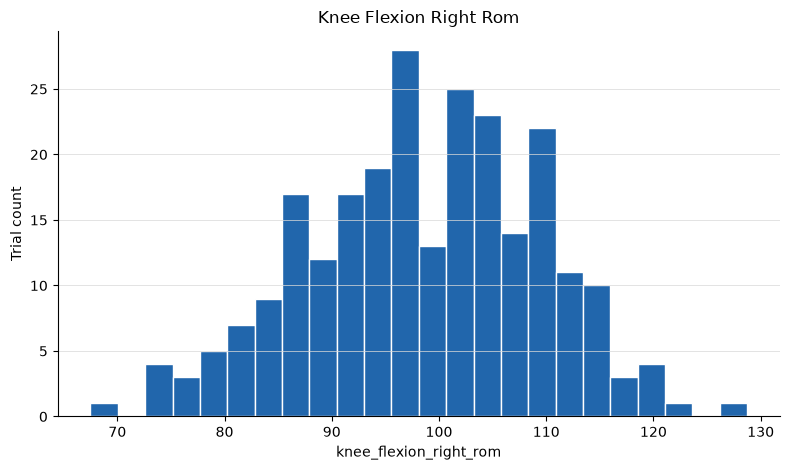

In [6]:
plot_feature_distribution(feature_frame, 'knee_flexion_right_rom');

## 6. Correlation Heatmap

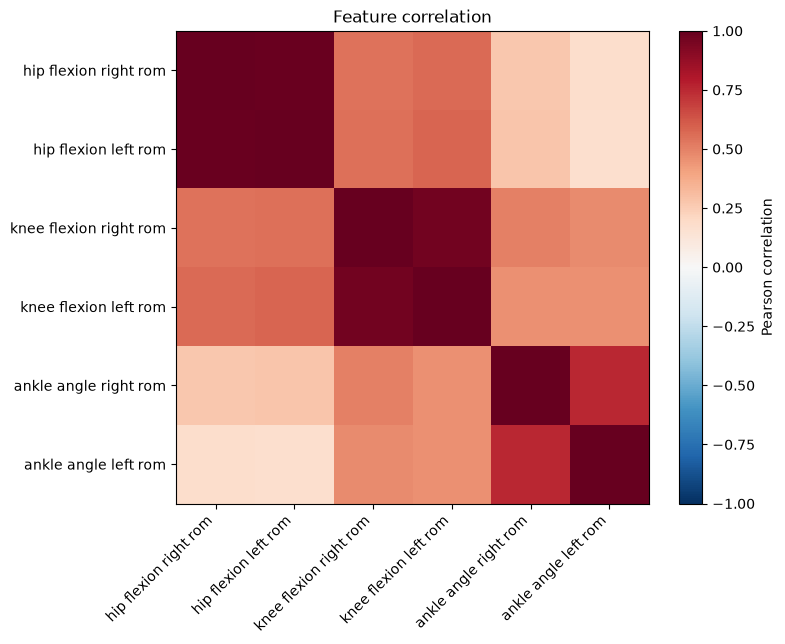

In [7]:
correlation_features = (
    'hip_flexion_right_rom',
    'hip_flexion_left_rom',
    'knee_flexion_right_rom',
    'knee_flexion_left_rom',
    'ankle_angle_right_rom',
    'ankle_angle_left_rom',
)
plot_correlation_heatmap(feature_frame, correlation_features);

## 7. Left/Right Comparison

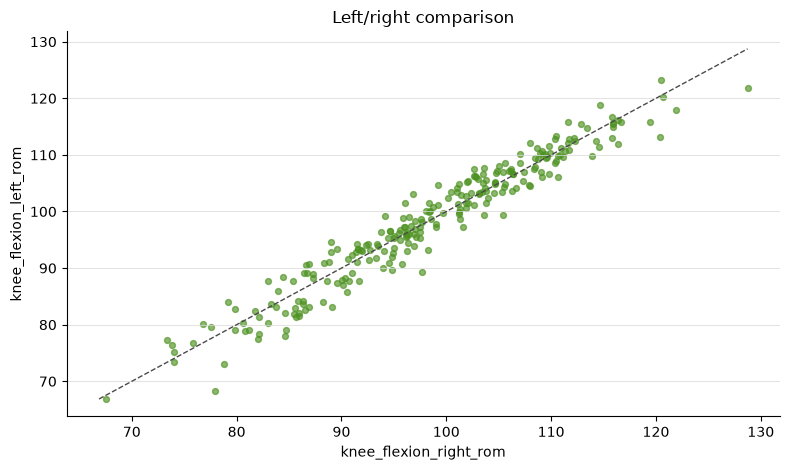

In [8]:
plot_left_right_comparison(
    feature_frame,
    'knee_flexion_left_rom',
    'knee_flexion_right_rom',
);

## 8. Time-Series Overlay

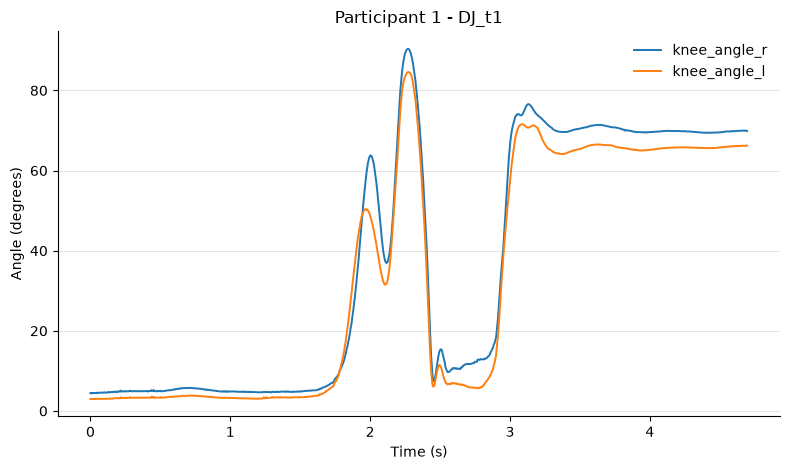

In [9]:
plot_time_series_overlay(trial, ('knee_angle_r', 'knee_angle_l'));

## 9. Determinism Check

In [10]:
repeated = dataset.extract_features(extractor)
assert feature_frame.equals(repeated)
'Repeated extraction is deterministic.'

'Repeated extraction is deterministic.'

## 10. Export

In [11]:
exported_path = export_features(feature_frame, OUTPUT_PATH)
exported_path

PosixPath('/Users/arnavanney/Documents/JumpguardAI/data/processed/features.csv')

## Limitations

- The feature window is the full recording, not a landing phase.
- Event-derived duration features are omitted because K/A are undefined.
- Empty trials remain rows with NaN feature values.
- Symmetry values are measurements, not injury-risk classifications.